# MunchLink Food Hub - Data Analysis

## Background

MunchLink is a food delivery platform operating across multiple city zones. With thousands of orders flowing through the platform, the business needs to understand what's working and what isn't  from delivery times and customer ratings to restaurant performance and revenue.

This analysis looks at 1,898 orders to answer some key operational and business questions:

- How many customers aren't leaving ratings, and why does that matter?
- Which restaurants are driving the most volume?
- Where are deliveries taking too long?
- Which zones have the most service problems?
- How is commission revenue distributed across cuisines and order types?

The goal is to get a clear picture of platform performance and spot areas that need attention.

## Objective

Work through the data to understand MunchLink's order patterns, delivery performance, and customer behaviour and pull out findings that are actually useful for decision making.

## Data Dictionary

| Column | Description |
|--------|-------------|
| order_id | Unique order identifier |
| customer_id | Customer identifier |
| restaurant_name | Restaurant name |
| cuisine_type | Cuisine category |
| cost_of_the_order | Order cost (USD) |
| day_of_the_week | Weekday or Weekend |
| rating | Customer rating (1-5 or Not given) |
| food_preparation_time | Prep time (minutes) |
| delivery_time | Delivery time (minutes) |
| total_fulfillment_time | Total prep + delivery time |
| prep_to_delivery_ratio | Prep speed vs delivery speed ratio |
| cost_bucket | Order cost category (Budget/Standard/Premium/Luxury) |
| speed_bucket | Fulfillment speed category |
| weather_condition | Weather condition |
| delivery_zone | Delivery zone (Downtown/Midtown/Uptown/Suburban) |
| is_group_order | Group order flag |
| service_issue_flag | Service issue flag |
| platform_commission | Platform commission (USD) |

In [1]:
#Import libraries for data manipulation
import numpy as np
import pandas as pd

#Import libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt


## Data Exploration & Structure

Let's start by understanding the dataset structure and quality.

In [2]:
#Read the data
df = pd.read_csv('munchlink_orders_enhanced.csv')

#Return the first 5 rows of the dataframe
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_fulfillment_time,prep_to_delivery_ratio,cost_bucket,speed_bucket,weather_condition,delivery_zone,is_group_order,service_issue_flag,platform_commission
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,45,1.25,Luxury,Normal,Rainy,Uptown,Yes,No,7.69
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,48,1.09,Standard,Normal,Cloudy,Uptown,No,No,1.81
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,51,0.82,Standard,Normal,Cloudy,Midtown,No,No,1.83
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,40,1.67,Premium,Fast,Rainy,Downtown,Yes,No,7.30
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,49,1.04,Standard,Normal,Rainy,Downtown,No,No,1.74


In [3]:
#Returns the last 5 rows of the dataframe
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_fulfillment_time,prep_to_delivery_ratio,cost_bucket,speed_bucket,weather_condition,delivery_zone,is_group_order,service_issue_flag,platform_commission
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17,48,1.82,Premium,Normal,Sunny,Suburban,Yes,No,5.58
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19,50,1.63,Standard,Normal,Sunny,Midtown,No,No,1.83
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24,55,1.29,Premium,Normal,Sunny,Downtown,Yes,No,6.30
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31,54,0.74,Standard,Normal,Cloudy,Midtown,No,No,1.83
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24,52,1.17,Standard,Normal,Sunny,Suburban,No,No,2.92


In [4]:
#Returns data types of each column
print("Data types:")
df.dtypes

Data types:


order_id                    int64
customer_id                 int64
restaurant_name            object
cuisine_type               object
cost_of_the_order         float64
day_of_the_week            object
rating                     object
food_preparation_time       int64
delivery_time               int64
total_fulfillment_time      int64
prep_to_delivery_ratio    float64
cost_bucket                object
speed_bucket               object
weather_condition          object
delivery_zone              object
is_group_order             object
service_issue_flag         object
platform_commission       float64
dtype: object

In [5]:
#Returns a concise summary of the dataframe, including data types, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                1898 non-null   int64  
 1   customer_id             1898 non-null   int64  
 2   restaurant_name         1898 non-null   object 
 3   cuisine_type            1898 non-null   object 
 4   cost_of_the_order       1898 non-null   float64
 5   day_of_the_week         1898 non-null   object 
 6   rating                  1898 non-null   object 
 7   food_preparation_time   1898 non-null   int64  
 8   delivery_time           1898 non-null   int64  
 9   total_fulfillment_time  1898 non-null   int64  
 10  prep_to_delivery_ratio  1898 non-null   float64
 11  cost_bucket             1898 non-null   object 
 12  speed_bucket            1898 non-null   object 
 13  weather_condition       1898 non-null   object 
 14  delivery_zone           1898 non-null   

### Question 3: Are there missing values in the data? How should we handle them?

In [6]:
#Returns missing values in each column
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


order_id                  0
customer_id               0
restaurant_name           0
cuisine_type              0
cost_of_the_order         0
day_of_the_week           0
rating                    0
food_preparation_time     0
delivery_time             0
total_fulfillment_time    0
prep_to_delivery_ratio    0
cost_bucket               0
speed_bucket              0
weather_condition         0
delivery_zone             0
is_group_order            0
service_issue_flag        0
platform_commission       0
dtype: int64

In [15]:
# Replace 'Not given' with NaN so missing ratings are handled consistently

df['rating'] = df['rating'].replace('Not given', np.nan)
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')

In [8]:
#Returns summary statistics for numerical columns in the dataframe, including count, mean, std, min, 25th percentile, median, 75th percentile, and max
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time,total_fulfillment_time,prep_to_delivery_ratio,platform_commission
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749,51.533720,1.187608,3.248946
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637,6.833603,0.340414,2.295686
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000,35.000000,0.610000,0.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000,47.000000,0.940000,1.810000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000,52.000000,1.130000,2.120000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000,56.000000,1.360000,5.577500
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000,68.000000,2.330000,8.850000


### Question 4: What is the overall rating distribution? How many orders lack ratings?

In [9]:
#Returns the orders that did not receive a rating
not_rating = df['rating'].fillna('Not given').value_counts()
print(not_rating)
print(f'Orders with no rating: {not_rating.get("Not given", 0)}')


rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
Orders with no rating: 736


## Exploratory Data Analysis (EDA)

### Question 5: Univariate checks for IDs and key operational distributions

#### a. Order ID (Uniqueness Check)

In [10]:
#Check the unique order ID
df['order_id'].nunique()

1898

#### b. Customer ID (Uniqueness Check)

In [11]:
# check unique customer ID
df['customer_id'].nunique()  

1200

#### c. Restaurant Name (Uniqueness Check)

In [12]:
# c. check unique restaurant name
df['restaurant_name'].nunique()

178

#### d. Key Operational Distributions

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Rating distribution
df['rating_num'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# Prep time distribution
axes[0, 1].hist(df['food_preparation_time'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Food Preparation Time Distribution')
axes[0, 1].set_xlabel('Minutes')
axes[0, 1].set_ylabel('Frequency')

# Cost bucket distribution
df['cost_bucket'].value_counts().plot(kind='bar', ax=axes[0, 2], color='coral')
axes[0, 2].set_title('Cost Bucket Distribution')
axes[0, 2].set_xlabel('Cost Bucket')
axes[0, 2].set_ylabel('Count')

# Speed bucket distribution
df['speed_bucket'].value_counts().plot(kind='bar', ax=axes[1, 0], color='plum')
axes[1, 0].set_title('Speed Bucket Distribution')
axes[1, 0].set_xlabel('Speed Bucket')
axes[1, 0].set_ylabel('Count')

# Delivery zone distribution
df['delivery_zone'].value_counts().plot(kind='bar', ax=axes[1, 1], color='khaki')
axes[1, 1].set_title('Delivery Zone Distribution')
axes[1, 1].set_xlabel('Zone')
axes[1, 1].set_ylabel('Count')

# Service issue flag distribution
df['service_issue_flag'].value_counts().plot(kind='bar', ax=axes[1, 2], color='lightcoral')
axes[1, 2].set_title('Service Issue Flag Distribution')
axes[1, 2].set_xlabel('Service Issue')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

KeyError: 'rating_num'

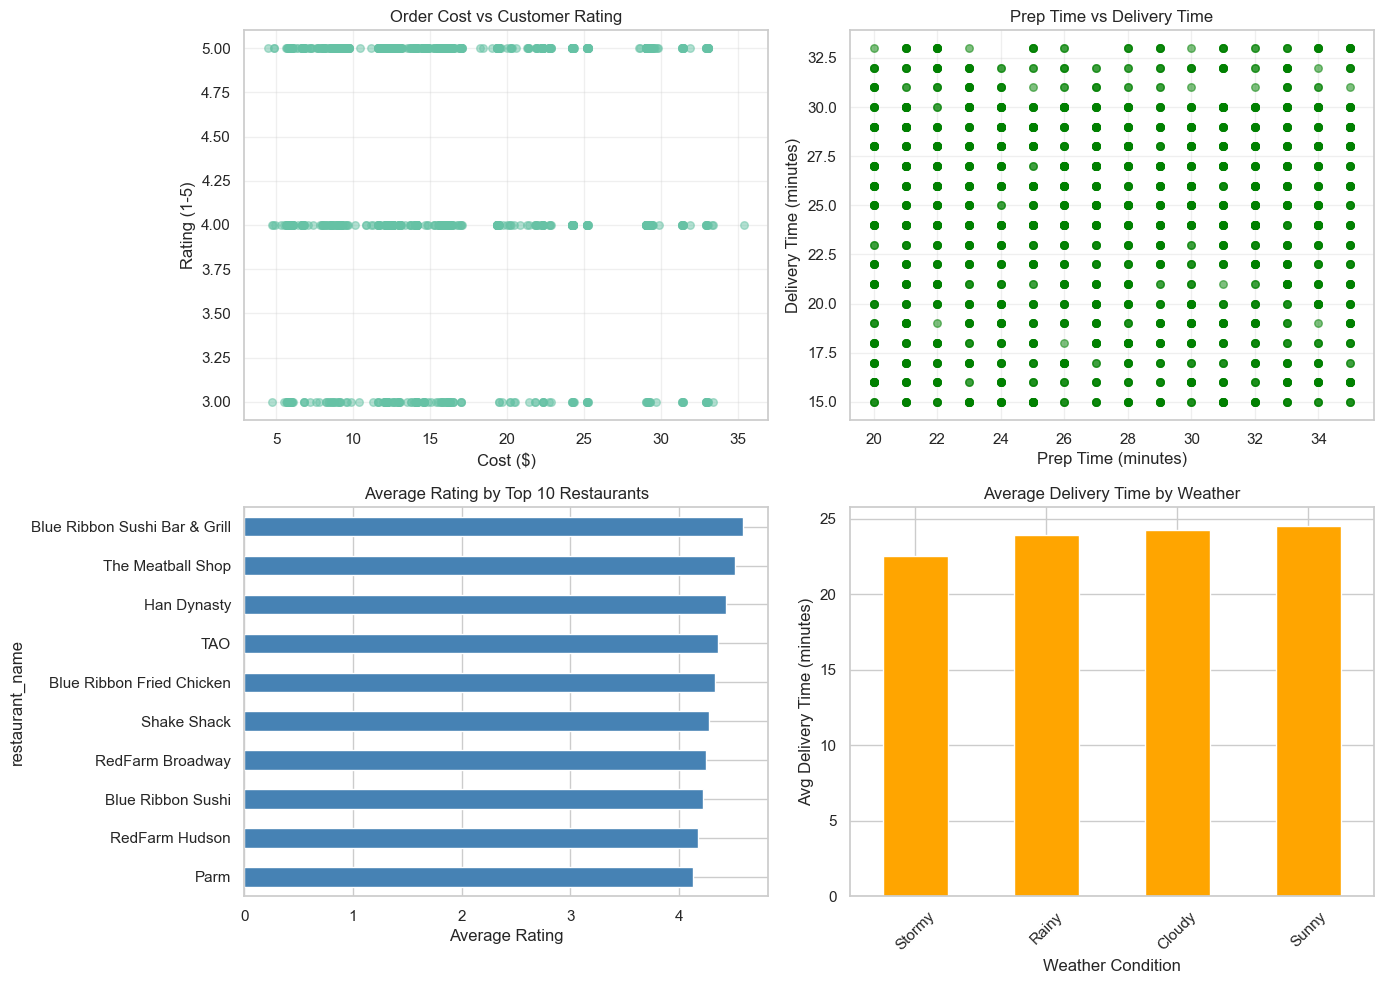

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: Cost vs Rating
scatter_data = df.dropna(subset=['rating_num'])
axes[0, 0].scatter(scatter_data['cost_of_the_order'], scatter_data['rating_num'], alpha=0.5, s=30)
axes[0, 0].set_title('Order Cost vs Customer Rating')
axes[0, 0].set_xlabel('Cost ($)')
axes[0, 0].set_ylabel('Rating (1-5)')
axes[0, 0].grid(True, alpha=0.3)

# Scatter: Prep Time vs Delivery Time
axes[0, 1].scatter(df['food_preparation_time'], df['delivery_time'], alpha=0.5, s=30, color='green')
axes[0, 1].set_title('Prep Time vs Delivery Time')
axes[0, 1].set_xlabel('Prep Time (minutes)')
axes[0, 1].set_ylabel('Delivery Time (minutes)')
axes[0, 1].grid(True, alpha=0.3)

# Average rating by top 10 restaurants
top_restaurants = df['restaurant_name'].value_counts().head(10).index
restaurant_ratings = df[df['restaurant_name'].isin(top_restaurants)].dropna(subset=['rating_num']).groupby('restaurant_name')['rating_num'].mean().sort_values()
restaurant_ratings.plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Average Rating by Top 10 Restaurants')
axes[1, 0].set_xlabel('Average Rating')

# Weather condition vs delivery time
weather_delivery = df.groupby('weather_condition')['delivery_time'].mean().sort_values()
weather_delivery.plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Average Delivery Time by Weather')
axes[1, 1].set_xlabel('Weather Condition')
axes[1, 1].set_ylabel('Avg Delivery Time (minutes)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

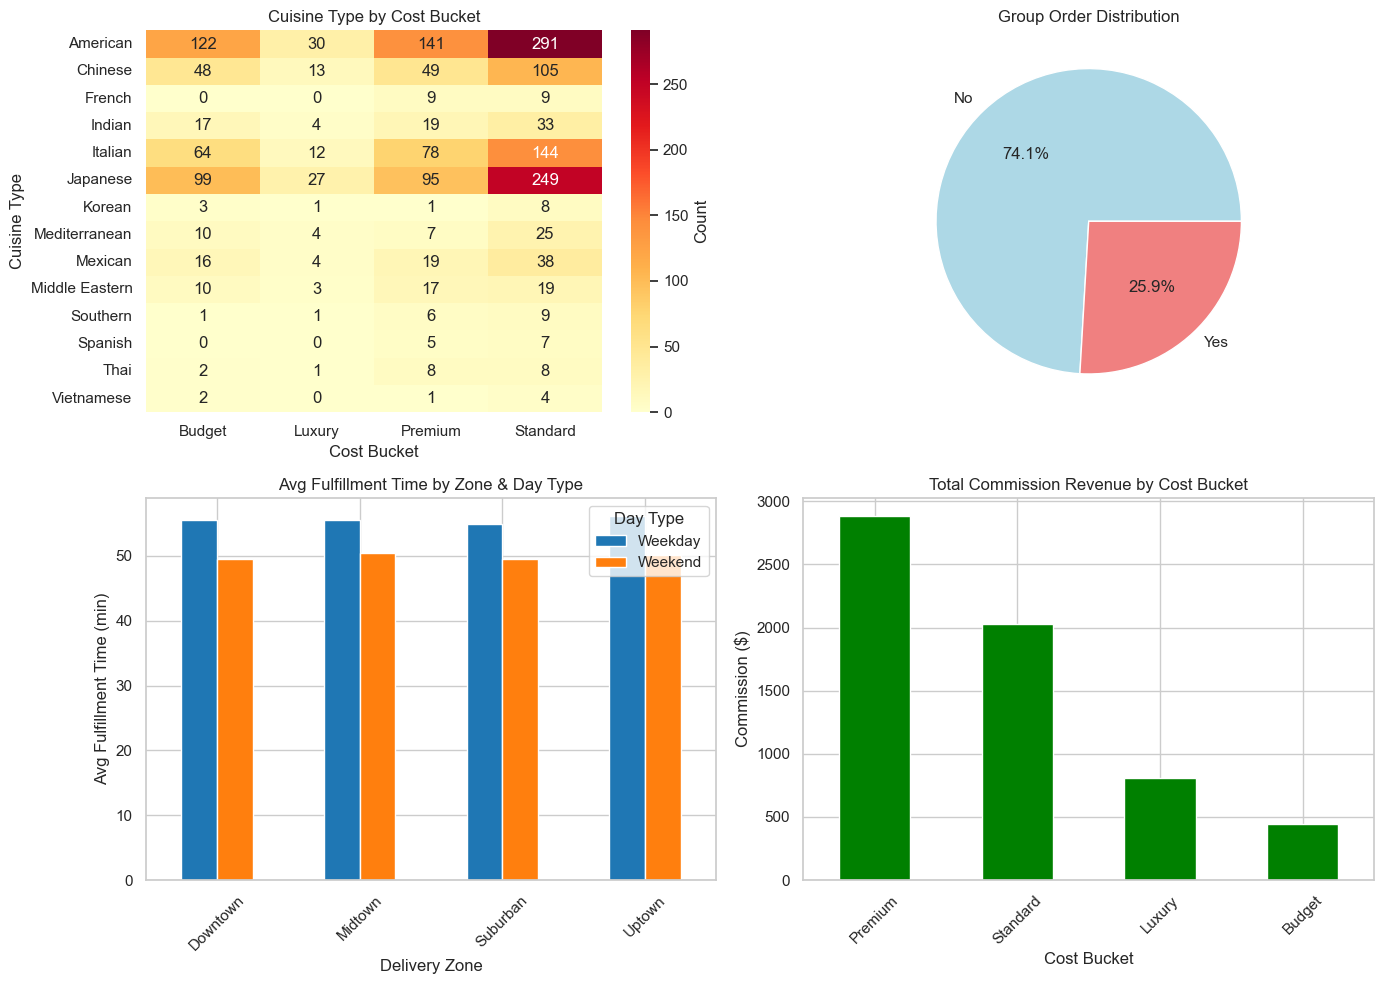

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cuisine by Cost Bucket (crosstab heatmap)
cuisine_cost_crosstab = pd.crosstab(df['cuisine_type'], df['cost_bucket'])
sns.heatmap(cuisine_cost_crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Cuisine Type by Cost Bucket')
axes[0, 0].set_xlabel('Cost Bucket')
axes[0, 0].set_ylabel('Cuisine Type')

# Group order analysis
group_order_stats = df['is_group_order'].value_counts()
group_order_stats.plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[0, 1].set_title('Group Order Distribution')
axes[0, 1].set_ylabel('')

# Total fulfillment time by zone and day type
fulfillment_by_zone_day = df.groupby(['delivery_zone', 'day_of_the_week'])['total_fulfillment_time'].mean().unstack()
fulfillment_by_zone_day.plot(kind='bar', ax=axes[1, 0], color=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_title('Avg Fulfillment Time by Zone & Day Type')
axes[1, 0].set_xlabel('Delivery Zone')
axes[1, 0].set_ylabel('Avg Fulfillment Time (min)')
axes[1, 0].legend(title='Day Type')
axes[1, 0].tick_params(axis='x', rotation=45)

# Platform commission by cost bucket
commission_by_bucket = df.groupby('cost_bucket')['platform_commission'].sum().sort_values(ascending=False)
commission_by_bucket.plot(kind='bar', ax=axes[1, 1], color='green')
axes[1, 1].set_title('Total Commission Revenue by Cost Bucket')
axes[1, 1].set_xlabel('Cost Bucket')
axes[1, 1].set_ylabel('Commission ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

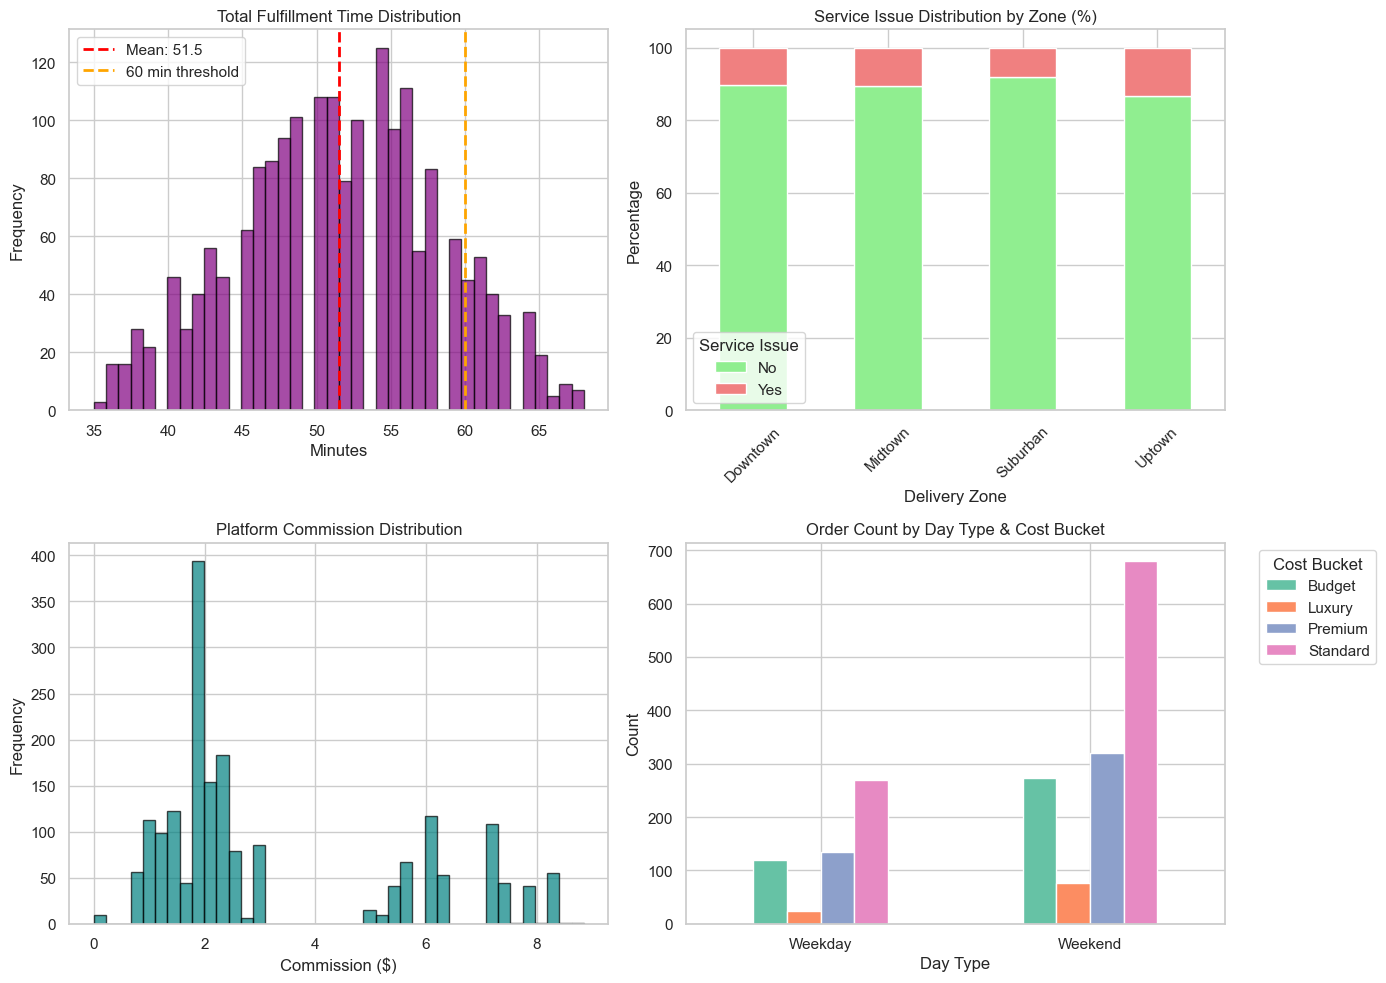

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total fulfillment time distribution with KDE
axes[0, 0].hist(df['total_fulfillment_time'], bins=40, alpha=0.7, color='purple', edgecolor='black')
axes[0, 0].axvline(df['total_fulfillment_time'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["total_fulfillment_time"].mean():.1f}')
axes[0, 0].axvline(60, color='orange', linestyle='--', linewidth=2, label='60 min threshold')
axes[0, 0].set_title('Total Fulfillment Time Distribution')
axes[0, 0].set_xlabel('Minutes')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Service issue flag by zone (stacked)
issue_zone = pd.crosstab(df['delivery_zone'], df['service_issue_flag'], normalize='index') * 100
issue_zone.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['lightgreen', 'lightcoral'])
axes[0, 1].set_title('Service Issue Distribution by Zone (%)')
axes[0, 1].set_xlabel('Delivery Zone')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].legend(title='Service Issue')
axes[0, 1].tick_params(axis='x', rotation=45)

# Platform commission distribution (log scale for better visibility)
axes[1, 0].hist(df['platform_commission'], bins=40, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Platform Commission Distribution')
axes[1, 0].set_xlabel('Commission ($)')
axes[1, 0].set_ylabel('Frequency')

# Orders by day type and cost bucket
day_cost = pd.crosstab(df['day_of_the_week'], df['cost_bucket'])
day_cost.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Order Count by Day Type & Cost Bucket')
axes[1, 1].set_xlabel('Day Type')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Cost Bucket', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Advanced EDA: Relationship Analysis

## Business Questions & Answers

### Q1. How many orders are not rated? What is their distribution and business impact?

This is computed in the earlier rating-quality check section (Question 4) to avoid duplication.

### Q2. What are the core order patterns across cost, delivery time, cuisine, and day type?

#### Analysis

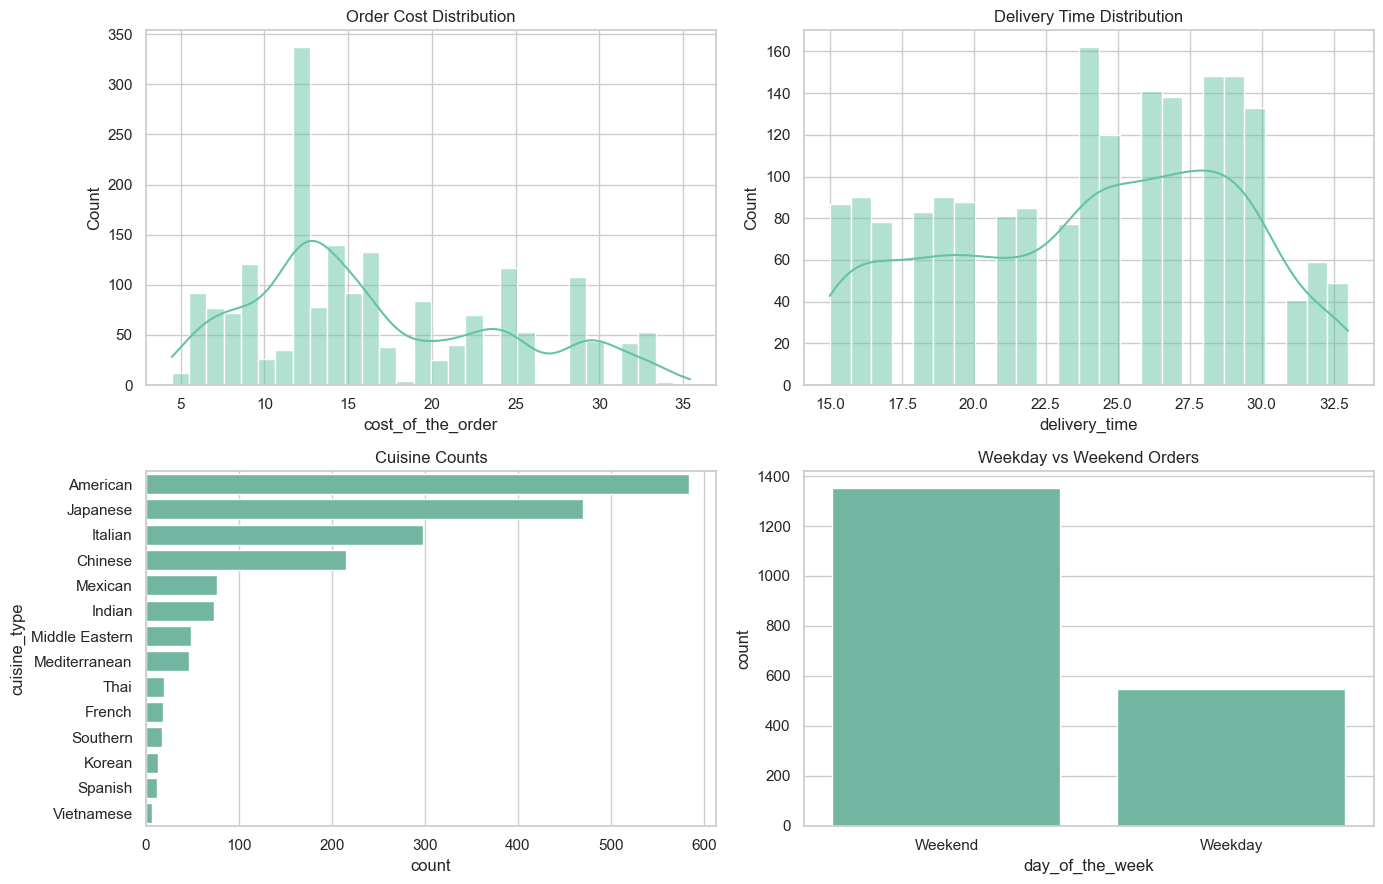

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(df['cost_of_the_order'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Order Cost Distribution')

sns.histplot(df['delivery_time'], bins=25, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time Distribution')

sns.countplot(data=df, y='cuisine_type', order=df['cuisine_type'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title('Cuisine Counts')

sns.countplot(data=df, x='day_of_the_week', ax=axes[1, 1])
axes[1, 1].set_title('Weekday vs Weekend Orders')

plt.tight_layout()
plt.show()

### Q3. Which restaurants receive the highest number of orders?

#### Analysis

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


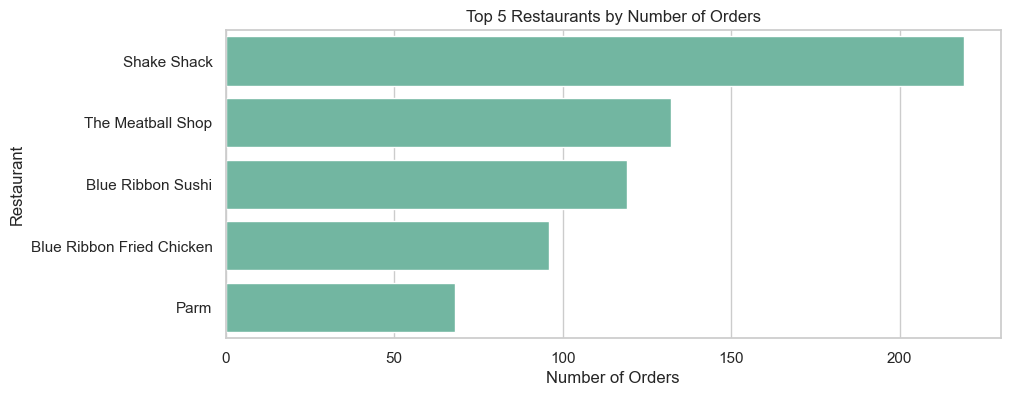

In [ ]:
top5_restaurants = df['restaurant_name'].value_counts().head(5)
print(top5_restaurants)

plt.figure(figsize=(10, 4))
sns.barplot(x=top5_restaurants.values, y=top5_restaurants.index)
plt.title('Top 5 Restaurants by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant')
plt.show()

### Q4. Which cuisine types are most popular during weekends?

#### Analysis

In [ ]:
weekend_top = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()
print(weekend_top.head(5))

cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64


### Q5. What percentage of orders are high-value orders (cost > $20)?

#### Analysis

In [ ]:
pct_gt_20 = (df['cost_of_the_order'] > 20).mean() * 100
print(f'Percentage of orders > $20: {pct_gt_20:.2f}%')

Percentage of orders > $20: 29.24%


### Q6. What is the average delivery time across all orders?

#### Analysis

In [ ]:
mean_delivery_time = df['delivery_time'].mean()
print(f'Mean delivery time: {mean_delivery_time:.2f} minutes')

Mean delivery time: 24.16 minutes


### Q7. Who are the most frequent customers on the platform?

#### Analysis

In [ ]:
top_customers = df['customer_id'].value_counts().head(3)
print(top_customers)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


### Q8. What relationships exist among key numeric variables and delivery timing?

#### Analysis

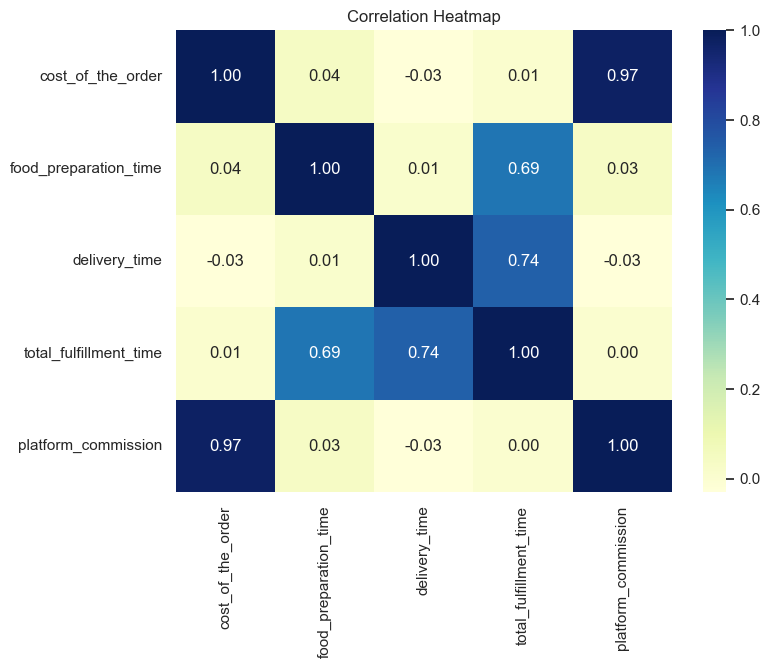

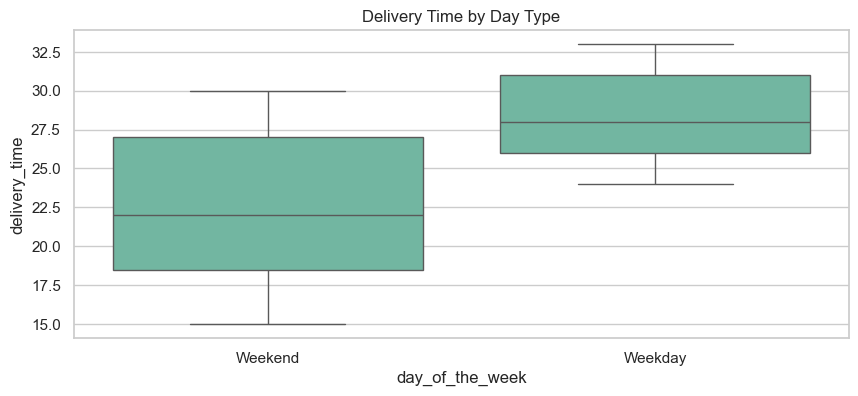

In [ ]:
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'total_fulfillment_time', 'platform_commission']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.title('Delivery Time by Day Type')
plt.show()

### Q9. Which restaurants show strong customer ratings at scale?

#### Analysis

In [ ]:
promo = (
    df.dropna(subset=['rating_num'])
    .groupby('restaurant_name')['rating_num']
    .agg(['count', 'mean'])
    .query('count > 50 and mean > 4')
    .sort_values('mean', ascending=False)
)
promo

,count,mean
restaurant_name,,
The Meatball Shop,84,4.511905
Blue Ribbon Fried Chicken,64,4.328125
Shake Shack,133,4.278195
Blue Ribbon Sushi,73,4.219178


### Q10. What is the total platform commission revenue?

#### Analysis

In [ ]:
net_revenue = df['platform_commission'].sum()
print(f'Estimated net platform revenue: ${net_revenue:,.2f}')

Estimated net platform revenue: $6,166.50


### Q11. What share of orders exceed the 60-minute fulfillment threshold?

#### Analysis

In [ ]:
pct_over_60 = (df['total_fulfillment_time'] > 60).mean() * 100
print(f'Orders with total fulfillment time > 60 minutes: {pct_over_60:.2f}%')

Orders with total fulfillment time > 60 minutes: 10.54%


### Q12. How does average delivery time differ between weekdays and weekends?

#### Analysis

In [ ]:
delivery_by_day = df.groupby('day_of_the_week')['delivery_time'].mean().round(2)
print(delivery_by_day)

day_of_the_week
Weekday    28.34
Weekend    22.47
Name: delivery_time, dtype: float64


### Q13. How do customer ratings vary across fulfillment speed buckets?

#### Analysis

In [ ]:
rating_by_speed = df.dropna(subset=['rating_num']).groupby('speed_bucket', observed=False)['rating_num'].mean().round(2)
print(rating_by_speed)

speed_bucket
Fast      4.43
Normal    4.33
Slow      4.36
Name: rating_num, dtype: float64


### Q14. Which delivery zones have the highest service issue rates?

#### Analysis

In [ ]:
issue_rate_by_zone = (
    df.groupby('delivery_zone')['service_issue_flag']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)
print(issue_rate_by_zone)

delivery_zone
Uptown      13.22
Midtown     10.49
Downtown    10.38
Suburban     8.01
Name: service_issue_flag, dtype: float64


### Q15. Which cuisine categories generate the most platform commission?

#### Analysis and Visualization

cuisine_type
American          1878.35
Japanese          1478.26
Italian            966.97
Chinese            690.04
Mexican            256.73
Indian             247.00
Middle Eastern     193.52
Mediterranean      136.32
Thai                78.05
French              76.19
Name: platform_commission, dtype: float64


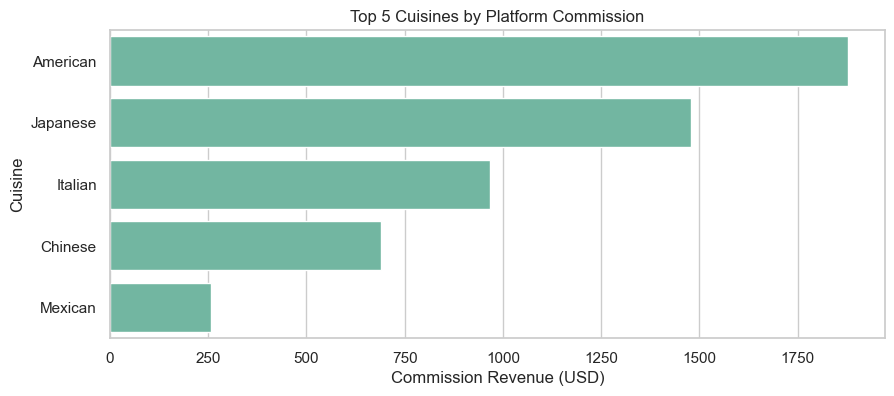

In [ ]:
commission_by_cuisine = df.groupby('cuisine_type')['platform_commission'].sum().sort_values(ascending=False).round(2)
print(commission_by_cuisine.head(10))

plt.figure(figsize=(10, 4))
top_commission = commission_by_cuisine.head(5)
sns.barplot(x=top_commission.values, y=top_commission.index)
plt.title('Top 5 Cuisines by Platform Commission')
plt.xlabel('Commission Revenue (USD)')
plt.ylabel('Cuisine')
plt.show()

## Summary & Business Recommendations

## Summary

### Key Findings

- 736 orders (38.8%) have no rating
- 10.54% of orders exceed 60-minute fulfillment time
- Shake Shack leads with 219 orders
- American cuisine dominates with 415 orders on weekends
- Average delivery time: 24.16 minutes
- Total platform commission: $6,166.50
- Weekday deliveries take longer (28.34 min) than weekend (22.47 min)
- Uptown zone has highest service issue rate (13.22%)